# Network Flow Inference Notebook
XGBoost inference on labeled flow CSVs with optional ground truth evaluation.

**Pipeline:** Load → Preprocess → Infer → Evaluate vs ground truth → Visualize

In [1]:
import sys
print(sys.executable)

import os

# Check if we are currently inside the 'notebooks' folder
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..') # Move up one level to the project root

print("Corrected Working Directory:", os.getcwd())

/home/cpre560/miniconda3/envs/cpre560/bin/python
Corrected Working Directory: /home/cpre560/Desktop/IDS-ML


In [2]:
# === CELL 1: Imports & Paths ===
import xgboost as xgb
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score, precision_score, recall_score,
)
from IPython.display import display

# ── Paths ─────────────────────────────────────────────────────────────────
MODEL_PATH      = 'models/baseline_xgboost.json'
ARTIFACTS_PATH  = 'models/preprocessing_info.pkl'
RENAME_MAP_PATH = 'src/preprocessing/rename_map.pkl'  # fixed path
CSV_PATH        = 'data/flows.csv'                    # VM-generated flows
OUT_DIR         = Path('output')
OUT_DIR.mkdir(exist_ok=True)

# Ground truth column — set to None to skip GT evaluation
GROUND_TRUTH_COL = 'Label'
CONF_THRESHOLD   = 0.90

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#f8f8f8',
    'axes.spines.top':  False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.4,
    'font.size': 11,
})
PALETTE = {'BENIGN': '#1D9E75', 'DDoS': '#D85A30', 'other': '#7F77DD'}
print('Imports OK')
print(f'   CSV : {CSV_PATH}')
print(f'   Out : {OUT_DIR.absolute()}')

Imports OK
   CSV : data/flows.csv
   Out : /home/cpre560/Desktop/IDS-ML/output


In [3]:
# === CELL 2: Load Model & Artifacts ===
model = xgb.XGBClassifier()
model.load_model(MODEL_PATH)

with open(ARTIFACTS_PATH, 'rb') as f:
    artifacts = pickle.load(f)
le_target    = artifacts['target_encoder']
feature_cols = artifacts['feature_columns']

with open(RENAME_MAP_PATH, 'rb') as f:
    rename_map = pickle.load(f)

print(f'Model loaded')
print(f'Classes ({len(le_target.classes_)}) : {list(le_target.classes_)}')
print(f'Feature cols : {len(feature_cols)}')

Model loaded
Classes (12) : ['BENIGN', 'Bot', 'DDoS', 'DoS GoldenEye', 'DoS Hulk', 'DoS Slowhttptest', 'DoS slowloris', 'FTP-Patator', 'PortScan', 'SSH-Patator', 'Web Attack Brute Force', 'Web Attack XSS']
Feature cols : 78


/home/cpre560/miniconda3/envs/cpre560/lib/python3.10/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator LabelEncoder from version 1.8.0 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [4]:
# === CELL 3: Load & Preprocess CSV ===
df_raw = pd.read_csv(CSV_PATH)
df_raw.columns = df_raw.columns.str.strip()
df_raw.replace([np.inf, -np.inf], np.nan, inplace=True)
df_raw.rename(columns=rename_map, inplace=True)

# CICIDS2017 duplicate header fix
df_raw['Fwd Header Length.1'] = df_raw['Fwd Header Length']

# Stash ground truth BEFORE any row drops (preserves index alignment)
has_gt = GROUND_TRUTH_COL is not None and GROUND_TRUTH_COL in df_raw.columns
if has_gt:
    gt_series = df_raw[GROUND_TRUTH_COL].str.strip()
else:
    gt_series = None
    print(f"WARNING: '{GROUND_TRUTH_COL}' not found — skipping GT evaluation")

missing = [c for c in feature_cols if c not in df_raw.columns]
if missing:
    raise ValueError(f'Missing feature columns after rename: {missing}')

df_raw.dropna(subset=feature_cols, inplace=True)
X = df_raw[feature_cols]
if has_gt:
    y_true = gt_series.loc[df_raw.index]

print(f'Loaded {len(X):,} flows  |  {X.shape[1]} features')
if has_gt:
    print('\nGround truth distribution:')
    display(y_true.value_counts().rename_axis('Label').reset_index(name='Count'))

Loaded 117,274 flows  |  78 features

Ground truth distribution:


,Label,Count
0,DDoS,96777
1,DoS slowloris,15512
2,Web Attack Brute Force,2268
3,BENIGN,1658
4,PortScan,1025
5,Bot,11
6,SSH-Patator,11
7,FTP-Patator,8
8,DoS Hulk,4


In [5]:
# === CELL 4: Run Inference ===
y_pred       = model.predict(X)
y_pred_proba = model.predict_proba(X)
y_pred_label = le_target.inverse_transform(y_pred)
confidence   = y_pred_proba.max(axis=1)

results = pd.DataFrame(index=df_raw.index)
results['Predicted_Label']    = y_pred_label
results['Predicted_Class_ID'] = y_pred
results['Confidence']         = confidence.round(4)

if has_gt:
    results['Ground_Truth'] = y_true
    results['Correct']      = results['Predicted_Label'] == results['Ground_Truth']

for i, cls in enumerate(le_target.classes_):
    results[f'Prob_{cls}'] = y_pred_proba[:, i].round(4)

results.to_csv(OUT_DIR / 'inference_results.csv', index=False)
print(f'{len(results):,} predictions saved → output/inference_results.csv')
print('\nPrediction distribution:')
display(results['Predicted_Label'].value_counts().rename_axis('Predicted').reset_index(name='Count'))

117,274 predictions saved → output/inference_results.csv

Prediction distribution:


,Predicted,Count
0,BENIGN,117217
1,FTP-Patator,29
2,DoS Hulk,28


  PRIMARY METRICS (imbalance-aware)
  Macro F1           : 5.11%  ← main metric
  Macro Recall       : 22.06%  ← avg detection rate
  Macro Precision    : 3.22%
  Weighted F1        : 0.04%
  Accuracy           : 1.40%

  ATTACK DETECTION RATES (Recall per class)
  ────────────────────────────────────────────────────
  Bot                                 0/    11  (  0.0%)  error
  DDoS                                0/96,777  (  0.0%)  error
  DoS Hulk                            0/     4  (  0.0%)  error
  DoS slowloris                       0/15,512  (  0.0%)  error
  FTP-Patator                         8/     8  (100.0%)  
  PortScan                            0/ 1,025  (  0.0%)  error
  SSH-Patator                         0/    11  (  0.0%)  error
  Web Attack Brute Force              0/ 2,268  (  0.0%)  error
  ────────────────────────────────────────────────────
  BENIGN                          1,634/ 1,658  ( 98.6%)  

                        precision    recall  f1-score   sup

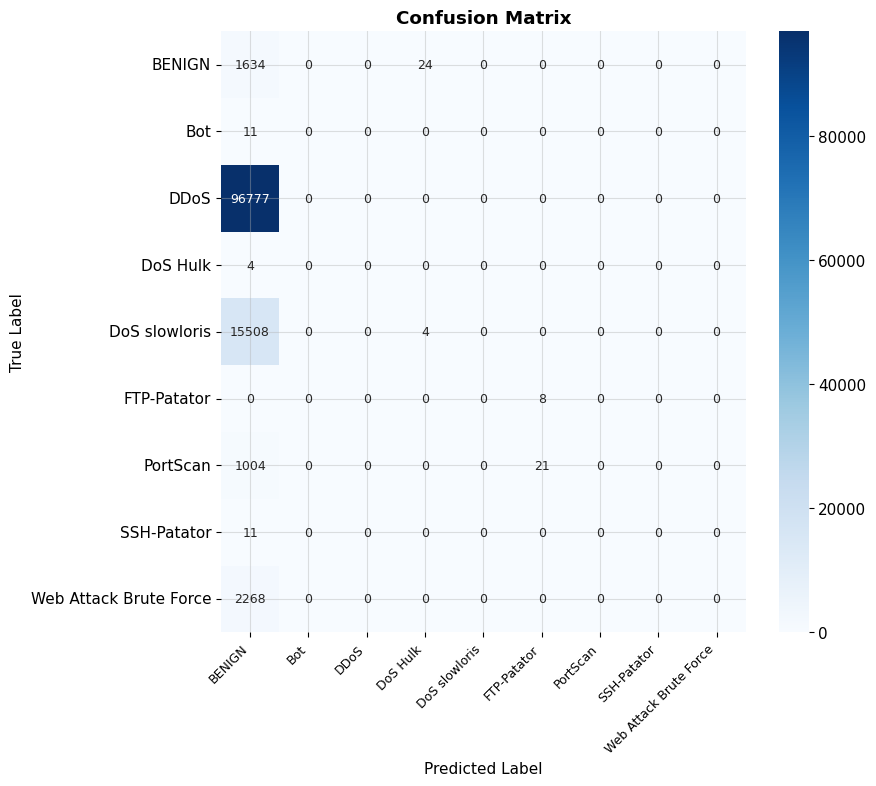

Saved → output/confusion_matrix.png
Misclassified : 115,632 / 117,274  (98.60%)
Saved → output/misclassified_flows.csv


In [6]:
# === CELL 5: Ground Truth Evaluation ===
if not has_gt:
    print('No ground truth — skipping evaluation.')
else:
    y_tv = results['Ground_Truth']
    y_pv = results['Predicted_Label']

    # ── Imbalance check ───────────────────────────────────────────────────
    gt_counts   = y_tv.value_counts()
    benign_pct  = gt_counts.get('BENIGN', 0) / len(y_tv) * 100
    is_imbalanced = benign_pct > 60

    if is_imbalanced:
        print('WARNING: Dataset is heavily imbalanced')
        print(f'   BENIGN flows : {gt_counts.get("BENIGN",0):,} ({benign_pct:.1f}%)')
        print(f'   Attack flows : {len(y_tv) - gt_counts.get("BENIGN",0):,} ({100-benign_pct:.1f}%)')
        print('   Accuracy is NOT a reliable metric here — a model that')
        print('   predicts BENIGN for everything will still score high.')
        print('   Use Macro F1 and per-class Recall (detection rate) instead.')
        print()

    # ── Metrics ───────────────────────────────────────────────────────────
    acc      = accuracy_score(y_tv, y_pv)
    f1_macro = f1_score(y_tv, y_pv, average='macro',    zero_division=0)
    f1_wt    = f1_score(y_tv, y_pv, average='weighted', zero_division=0)
    prec     = precision_score(y_tv, y_pv, average='macro', zero_division=0)
    rec      = recall_score(y_tv,    y_pv, average='macro', zero_division=0)

    # Lead with F1 — accuracy last and flagged if imbalanced
    print('=' * 55)
    print('  PRIMARY METRICS (imbalance-aware)')
    print('=' * 55)
    print(f'  Macro F1           : {f1_macro*100:.2f}%  ← main metric')
    print(f'  Macro Recall       : {rec*100:.2f}%  ← avg detection rate')
    print(f'  Macro Precision    : {prec*100:.2f}%')
    print(f'  Weighted F1        : {f1_wt*100:.2f}%')
    acc_flag = '  warning  inflated by class imbalance' if is_imbalanced else ''
    print(f'  Accuracy           : {acc*100:.2f}%{acc_flag}')
    print('=' * 55)
    print()

    # ── Per-attack detection rate table ───────────────────────────────────
    print('  ATTACK DETECTION RATES (Recall per class)')
    print('  ' + '─' * 52)
    attack_classes = [c for c in sorted(y_tv.unique()) if c != 'BENIGN']
    for cls in attack_classes + ['BENIGN']:
        gt_n    = (y_tv == cls).sum()
        det_n   = ((y_tv == cls) & (y_pv == cls)).sum()
        missed  = gt_n - det_n
        rate    = det_n / gt_n * 100 if gt_n > 0 else 0
        flag    = '  ' if rate >= 80 else ('  warning ' if rate >= 40 else '  error')
        sep     = '  ' + '─' * 52 if cls == 'BENIGN' else ''
        if sep: print(sep)
        print(f'  {cls:<30} {det_n:>6,}/{gt_n:>6,}  ({rate:>5.1f}%){flag}')
    print()

    # ── Full classification report ─────────────────────────────────────────
    print(classification_report(y_tv, y_pv, zero_division=0))

    # ── Confusion matrix ──────────────────────────────────────────────────
    present_classes = sorted(y_tv.unique())
    cm = confusion_matrix(y_tv, y_pv, labels=present_classes)
    fig, ax = plt.subplots(figsize=(max(8, len(present_classes)), max(6, len(present_classes)-1)))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=present_classes, yticklabels=present_classes, ax=ax,
                annot_kws={'size': 9})
    ax.set_title('Confusion Matrix', fontweight='bold')
    ax.set_ylabel('True Label'); ax.set_xlabel('Predicted Label')
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)
    plt.tight_layout()
    plt.savefig(OUT_DIR / 'confusion_matrix.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved → output/confusion_matrix.png')

    misclassified = results[~results['Correct']]
    misclassified.to_csv(OUT_DIR / 'misclassified_flows.csv', index=False)
    print(f'Misclassified : {len(misclassified):,} / {len(results):,}  '
          f'({len(misclassified)/len(results)*100:.2f}%)')
    print('Saved → output/misclassified_flows.csv')


In [7]:
# === CELL 6: Per-Class Performance Table ===
if not has_gt:
    print('No ground truth — skipping.')
else:
    y_tv = results['Ground_Truth']
    y_pv = results['Predicted_Label']
    report = classification_report(y_tv, y_pv, output_dict=True, zero_division=0)

    rows = []
    for cls in sorted(y_tv.unique()):
        gt_c  = int((y_tv == cls).sum())
        pd_c  = int((y_pv == cls).sum())
        corr  = int(((y_tv == cls) & (y_pv == cls)).sum())
        missed = gt_c - corr
        r = report.get(cls, {})
        recall = r.get('recall', 0)
        rows.append({
            'Attack Class':      cls,
            'GT Count':          gt_c,
            'Detected':          corr,
            'Missed':            missed,
            'Detection Rate %':  round(recall * 100, 2),   # recall = detection rate
            'Precision %':       round(r.get('precision', 0) * 100, 2),
            'F1 %':              round(r.get('f1-score',  0) * 100, 2),
        })

    perf_df = pd.DataFrame(rows)
    perf_df.to_csv(OUT_DIR / 'per_class_performance.csv', index=False)
    print('Saved → output/per_class_performance.csv')
    print('Detection Rate = Recall = what % of each attack type the model caught\n')
    display(perf_df.style
            .background_gradient(subset=['Detection Rate %', 'F1 %'], cmap='RdYlGn', vmin=0, vmax=100)
            .background_gradient(subset=['Missed'], cmap='Reds')
            .format('{:.2f}', subset=['Detection Rate %', 'Precision %', 'F1 %']))


Saved → output/per_class_performance.csv
Detection Rate = Recall = what % of each attack type the model caught



,Attack Class,GT Count,Detected,Missed,Detection Rate %,Precision %,F1 %
0,BENIGN,1658,1634,24,98.55,1.39,2.75
1,Bot,11,0,11,0.00,0.00,0.00
2,DDoS,96777,0,96777,0.00,0.00,0.00
3,DoS Hulk,4,0,4,0.00,0.00,0.00
4,DoS slowloris,15512,0,15512,0.00,0.00,0.00
5,FTP-Patator,8,8,0,100.00,27.59,43.24
6,PortScan,1025,0,1025,0.00,0.00,0.00
7,SSH-Patator,11,0,11,0.00,0.00,0.00
8,Web Attack Brute Force,2268,0,2268,0.00,0.00,0.00


/tmp/ipykernel_16663/2108438538.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0].boxplot(groups, labels=classes, patch_artist=True, zorder=2)


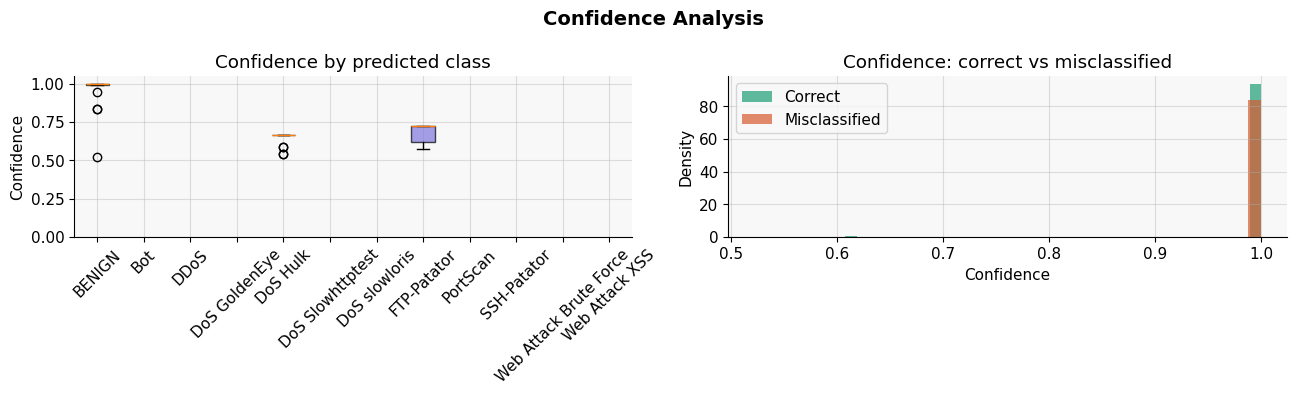

In [8]:
# === CELL 7: Confidence Analysis ===
classes = list(le_target.classes_)
colors  = [PALETTE.get(c, PALETTE['other']) for c in classes]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Confidence Analysis', fontsize=14, fontweight='bold')

groups = [results.loc[results['Predicted_Label']==c, 'Confidence'].values for c in classes]
bp = axes[0].boxplot(groups, labels=classes, patch_artist=True, zorder=2)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color); patch.set_alpha(0.7)
axes[0].set_title('Confidence by predicted class')
axes[0].set_ylabel('Confidence')
axes[0].set_ylim(0, 1.05)
axes[0].tick_params(axis='x', rotation=45)

if has_gt:
    axes[1].hist(results.loc[ results['Correct'],  'Confidence'], bins=40,
                 alpha=0.7, color='#1D9E75', label='Correct',       density=True)
    axes[1].hist(results.loc[~results['Correct'], 'Confidence'], bins=40,
                 alpha=0.7, color='#D85A30', label='Misclassified', density=True)
    axes[1].legend()
    axes[1].set_title('Confidence: correct vs misclassified')
else:
    axes[1].hist(results['Confidence'], bins=40, color='#7F77DD', alpha=0.8, density=True)
    axes[1].set_title('Overall confidence distribution')
axes[1].set_xlabel('Confidence'); axes[1].set_ylabel('Density')

plt.tight_layout()
plt.savefig(OUT_DIR / 'plot_confidence.png', dpi=150, bbox_inches='tight')
plt.show()

Flows below 90% confidence: 60 (0.05%)


Predicted_Label
FTP-Patator    29
DoS Hulk       28
BENIGN          3
Name: count, dtype: int64

Correct in low-conf set: 8/60 (13.3%)


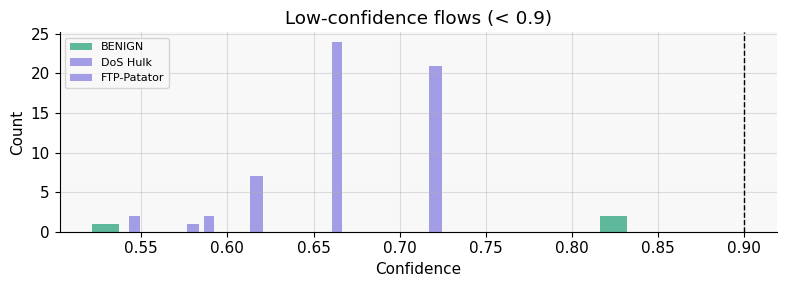

Saved → output/low_confidence_flows.csv


In [9]:
# === CELL 8: Low-Confidence Inspection ===
low_conf = results[results['Confidence'] < CONF_THRESHOLD].copy()
print(f'Flows below {CONF_THRESHOLD*100:.0f}% confidence: '
      f'{len(low_conf):,} ({len(low_conf)/len(results)*100:.2f}%)')

if len(low_conf) > 0:
    display(low_conf['Predicted_Label'].value_counts())
    if has_gt:
        lc_corr = low_conf['Correct'].sum()
        print(f'Correct in low-conf set: {lc_corr}/{len(low_conf)} '
              f'({lc_corr/len(low_conf)*100:.1f}%)')

    fig, ax = plt.subplots(figsize=(8, 3))
    for cls, color in zip(classes, colors):
        mask = low_conf['Predicted_Label'] == cls
        if mask.sum() > 0:
            ax.hist(low_conf.loc[mask, 'Confidence'], bins=20,
                    alpha=0.7, color=color, label=cls)
    ax.axvline(CONF_THRESHOLD, color='black', linestyle='--', linewidth=1)
    ax.set_title(f'Low-confidence flows (< {CONF_THRESHOLD})')
    ax.set_xlabel('Confidence'); ax.set_ylabel('Count')
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig(OUT_DIR / 'plot_low_confidence.png', dpi=150, bbox_inches='tight')
    plt.show()

    low_conf.to_csv(OUT_DIR / 'low_confidence_flows.csv', index=False)
    print('Saved → output/low_confidence_flows.csv')
else:
    print('No low-confidence flows — model is highly confident on all samples.')

In [10]:
# === CELL 9: Summary ===
gt_counts  = results['Ground_Truth'].value_counts() if has_gt else None
benign_pct = gt_counts.get('BENIGN', 0) / len(results) * 100 if has_gt else 0

print('=' * 55)
print('  INFERENCE RUN SUMMARY')
print('=' * 55)
print(f'  Input file      : {CSV_PATH}')
print(f'  Total flows     : {len(results):,}')
print(f'  Low-conf flows  : {len(results[results["Confidence"] < CONF_THRESHOLD]):,} (< {CONF_THRESHOLD})')
print(f'  Mean confidence : {results["Confidence"].mean():.4f}')
print()
if has_gt:
    f1  = f1_score(results['Ground_Truth'], results['Predicted_Label'], average='macro', zero_division=0)
    rec = recall_score(results['Ground_Truth'], results['Predicted_Label'], average='macro', zero_division=0)
    acc = accuracy_score(results['Ground_Truth'], results['Predicted_Label'])
    print(f'  Macro F1        : {f1*100:.2f}%  ← headline metric')
    print(f'  Macro Recall    : {rec*100:.2f}%  ← avg detection rate')
    acc_note = '  (warning  inflated — dataset is imbalanced)' if benign_pct > 60 else ''
    print(f'  Accuracy        : {acc*100:.2f}%{acc_note}')
    print()
    print('  DETECTION RATES:')
    y_tv = results['Ground_Truth']
    y_pv = results['Predicted_Label']
    for cls in sorted(y_tv.unique()):
        gt_n  = (y_tv == cls).sum()
        det_n = ((y_tv == cls) & (y_pv == cls)).sum()
        rate  = det_n / gt_n * 100 if gt_n > 0 else 0
        flag  = '' if rate >= 80 else ('warning ' if rate >= 40 else 'error ')
        print(f'  {flag} {cls:<28} {rate:>5.1f}%  ({det_n:,}/{gt_n:,})')
    print()
    print(f'  Misclassified   : {(~results["Correct"]).sum():,}')
else:
    print('  PREDICTIONS:')
    for cls in classes:
        n = (results['Predicted_Label'] == cls).sum()
        print(f'  {cls:<28} {n:>8,}  ({n/len(results)*100:.2f}%)')
print('=' * 55)
print()
print('Output files saved to output/')


  INFERENCE RUN SUMMARY
  Input file      : data/flows.csv
  Total flows     : 117,274
  Low-conf flows  : 60 (< 0.9)
  Mean confidence : 0.9952

  Macro F1        : 5.11%  ← headline metric
  Macro Recall    : 22.06%  ← avg detection rate
  Accuracy        : 1.40%

  DETECTION RATES:
   BENIGN                        98.6%  (1,634/1,658)
  error  Bot                            0.0%  (0/11)
  error  DDoS                           0.0%  (0/96,777)
  error  DoS Hulk                       0.0%  (0/4)
  error  DoS slowloris                  0.0%  (0/15,512)
   FTP-Patator                  100.0%  (8/8)
  error  PortScan                       0.0%  (0/1,025)
  error  SSH-Patator                    0.0%  (0/11)
  error  Web Attack Brute Force         0.0%  (0/2,268)

  Misclassified   : 115,632

Output files saved to output/
